<a href="https://colab.research.google.com/github/PavanMamidisetti/youtube-trend-analysis/blob/main/youtube_video_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Step-1:Loading Dataset

In [3]:
df = pd.read_csv("/content/INvideos.csv")
df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32477,8xUwwOmCSqs,18.18.05,Jitni Dafa |PARMANU:The Story Of Pokhran| John...,Zee Music Company,10,2018-05-17T09:37:34.000Z,"Jitni Dafa|""Jitni Dafa Song""|""Jitni Dafa New S...",3466219,33152,652,1949,https://i.ytimg.com/vi/8xUwwOmCSqs/default.jpg,False,False,False,Jeet Gannguli and Yasser Desai’s ‘Jitni Dafa’ ...
32478,Txsj-DgYbv4,18.18.05,Newly Married v/s 5 Years Later | Harshdeep Ah...,Harshdeep Ahuja,24,2018-05-17T06:46:18.000Z,"harshdeep ahuja|""harshdeep ahuja vines""|""harsh...",319702,27109,402,2412,https://i.ytimg.com/vi/Txsj-DgYbv4/default.jpg,False,False,False,Newly Married v/s 5 Years Later | Harshdeep Ah...
32479,312Uu9zFZQI,18.18.05,😃😝 ખજુરભાઈ નું ખેતર - khajubhai ni moj - IPL.10,Khajur Bhai Ni Moj,23,2018-05-16T06:39:18.000Z,"khajurbhai|""khajurbhai ni moj""|""khajur jigli""|...",384964,7488,316,333,https://i.ytimg.com/vi/312Uu9zFZQI/default.jpg,False,False,False,khajurbhai ni cricket ni moj (IPL) - ખજુરભાઈ ન...
32480,6S9c5nnDd_s,18.18.05,Bohemian Rhapsody | Teaser Trailer [HD] | 20th...,20th Century Fox,1,2018-05-15T13:01:12.000Z,"Trailer|""bohemian rhapsody""|""queen""|""freddie m...",9052821,279714,5398,17652,https://i.ytimg.com/vi/6S9c5nnDd_s/default.jpg,False,False,False,Visit http://www.PutMeInBohemian.com for a cha...


In [4]:
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...


#Step-2:Understand Dataset

In [5]:
df.columns

Index(['video_id', 'trending_date', 'title', 'channel_title', 'category_id',
       'publish_time', 'tags', 'views', 'likes', 'dislikes', 'comment_count',
       'thumbnail_link', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'description'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32482 entries, 0 to 32481
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                32482 non-null  object
 1   trending_date           32482 non-null  object
 2   title                   32482 non-null  object
 3   channel_title           32482 non-null  object
 4   category_id             32482 non-null  int64 
 5   publish_time            32482 non-null  object
 6   tags                    32482 non-null  object
 7   views                   32482 non-null  int64 
 8   likes                   32482 non-null  int64 
 9   dislikes                32482 non-null  int64 
 10  comment_count           32482 non-null  int64 
 11  thumbnail_link          32482 non-null  object
 12  comments_disabled       32482 non-null  bool  
 13  ratings_disabled        32482 non-null  bool  
 14  video_error_or_removed  32482 non-null  bool  
 15  de

In [7]:
df.isnull().sum()

,0
video_id,0
trending_date,0
title,0
channel_title,0
category_id,0
publish_time,0
tags,0
views,0
likes,0
dislikes,0


# Step-3:Data Cleaning

**Remove unnecessary** **columns**





In [8]:
df = df.drop(['thumbnail_link', 'description'], axis=1)

**Remove null values**

In [9]:
df = df.dropna()

**Remove duplicate rows**

In [10]:
df = df.drop_duplicates()

# Step-4:Convert Trending Date

In [11]:
df['trending_date'] = pd.to_datetime(df['trending_date'], errors='coerce')
df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,kzwfHumJyYc,NaT,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False
1,zUZ1z7FwLc8,NaT,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False
2,10L1hZ9qa58,NaT,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False
3,N1vE8iiEg64,NaT,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False
4,kJzGH0PVQHQ,NaT,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32455,qjKxo910e94,NaT,10 AWESOME LIFE HACKS!,Power Vision,24,2018-05-16T12:15:00.000Z,"Life hacks|""Coca-Cola Life hacks""|""Useful Life...",381550,1258,342,92,False,False,False
32456,MYnO9Gfh5ks,NaT,20 WEIRD BEAUTY HACKS TESTED,5-Minute Crafts,26,2018-05-17T18:30:00.000Z,"5-Minute Crafts|""DIY""|""Do it yourself""|""crafts...",855750,11570,1057,817,False,False,False
32458,y-PQiShdTKA,NaT,Tochan (Full Video) | SIDHU MOOSEWALA | BYG BY...,Humble Music,10,2018-05-17T07:35:47.000Z,"sidhu moosewala|""sidhu moose wala""|""sidhu moos...",5659320,112533,3180,10480,False,False,False
32459,XiHiW4N7-bo,NaT,Mission: Impossible - Fallout (2018) - Officia...,Paramount Pictures,1,2018-05-16T06:59:59.000Z,"Official Trailer|""Movie""|""New Movie""|""Film""|""O...",9978294,129866,3645,9539,False,False,False


# Step-5:Basic Data Analysis

**Most viewed videos**

In [12]:
top_views = df.sort_values(by='views', ascending=False)

top_views[['title', 'channel_title', 'views']].head(10)
df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,kzwfHumJyYc,NaT,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False
1,zUZ1z7FwLc8,NaT,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False
2,10L1hZ9qa58,NaT,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False
3,N1vE8iiEg64,NaT,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False
4,kJzGH0PVQHQ,NaT,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32455,qjKxo910e94,NaT,10 AWESOME LIFE HACKS!,Power Vision,24,2018-05-16T12:15:00.000Z,"Life hacks|""Coca-Cola Life hacks""|""Useful Life...",381550,1258,342,92,False,False,False
32456,MYnO9Gfh5ks,NaT,20 WEIRD BEAUTY HACKS TESTED,5-Minute Crafts,26,2018-05-17T18:30:00.000Z,"5-Minute Crafts|""DIY""|""Do it yourself""|""crafts...",855750,11570,1057,817,False,False,False
32458,y-PQiShdTKA,NaT,Tochan (Full Video) | SIDHU MOOSEWALA | BYG BY...,Humble Music,10,2018-05-17T07:35:47.000Z,"sidhu moosewala|""sidhu moose wala""|""sidhu moos...",5659320,112533,3180,10480,False,False,False
32459,XiHiW4N7-bo,NaT,Mission: Impossible - Fallout (2018) - Officia...,Paramount Pictures,1,2018-05-16T06:59:59.000Z,"Official Trailer|""Movie""|""New Movie""|""Film""|""O...",9978294,129866,3645,9539,False,False,False


# Step-6:Top Trending Categories

In [13]:
top_categories = df['category_id'].value_counts()

print(top_categories)
df

category_id
24    13187
25     4332
10     2855
23     2573
22     2183
1      1295
27     1026
26      705
17      595
28      456
43      121
29       86
2        69
20       42
19        8
15        3
30        2
Name: count, dtype: int64


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,kzwfHumJyYc,NaT,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False
1,zUZ1z7FwLc8,NaT,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False
2,10L1hZ9qa58,NaT,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False
3,N1vE8iiEg64,NaT,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False
4,kJzGH0PVQHQ,NaT,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32455,qjKxo910e94,NaT,10 AWESOME LIFE HACKS!,Power Vision,24,2018-05-16T12:15:00.000Z,"Life hacks|""Coca-Cola Life hacks""|""Useful Life...",381550,1258,342,92,False,False,False
32456,MYnO9Gfh5ks,NaT,20 WEIRD BEAUTY HACKS TESTED,5-Minute Crafts,26,2018-05-17T18:30:00.000Z,"5-Minute Crafts|""DIY""|""Do it yourself""|""crafts...",855750,11570,1057,817,False,False,False
32458,y-PQiShdTKA,NaT,Tochan (Full Video) | SIDHU MOOSEWALA | BYG BY...,Humble Music,10,2018-05-17T07:35:47.000Z,"sidhu moosewala|""sidhu moose wala""|""sidhu moos...",5659320,112533,3180,10480,False,False,False
32459,XiHiW4N7-bo,NaT,Mission: Impossible - Fallout (2018) - Officia...,Paramount Pictures,1,2018-05-16T06:59:59.000Z,"Official Trailer|""Movie""|""New Movie""|""Film""|""O...",9978294,129866,3645,9539,False,False,False


**Visualization:**

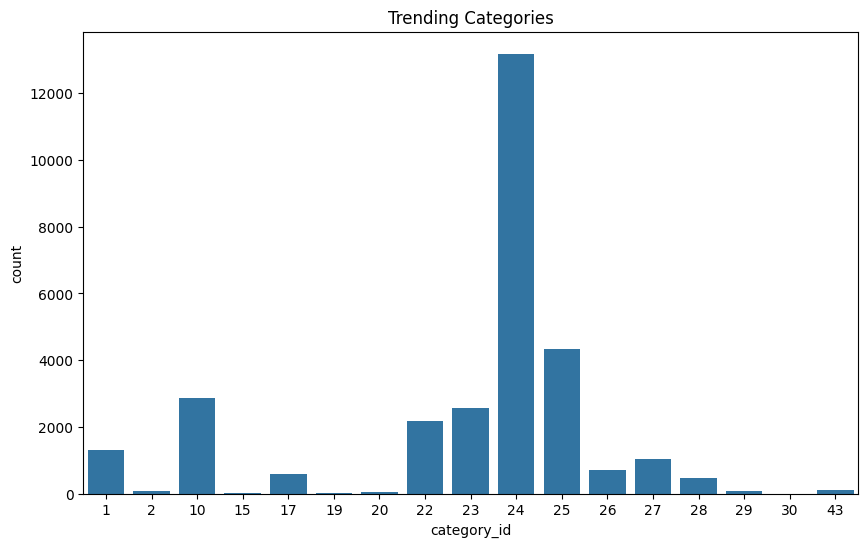

In [14]:
plt.figure(figsize=(10,6))
sns.countplot(x='category_id', data=df)
plt.title("Trending Categories")
plt.show()

# Step-7:Top Channels

In [15]:
top_channels = df['channel_title'].value_counts().head(10)

print(top_channels)
df

channel_title
VikatanTV             180
etvteluguindia        178
ETV Plus India        178
SAB TV                177
Study IQ education    176
Flowers Comedy        175
Tarang TV             172
SET India             172
Mazhavil Manorama     170
zeetv                 169
Name: count, dtype: int64


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,kzwfHumJyYc,NaT,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False
1,zUZ1z7FwLc8,NaT,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False
2,10L1hZ9qa58,NaT,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False
3,N1vE8iiEg64,NaT,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False
4,kJzGH0PVQHQ,NaT,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32455,qjKxo910e94,NaT,10 AWESOME LIFE HACKS!,Power Vision,24,2018-05-16T12:15:00.000Z,"Life hacks|""Coca-Cola Life hacks""|""Useful Life...",381550,1258,342,92,False,False,False
32456,MYnO9Gfh5ks,NaT,20 WEIRD BEAUTY HACKS TESTED,5-Minute Crafts,26,2018-05-17T18:30:00.000Z,"5-Minute Crafts|""DIY""|""Do it yourself""|""crafts...",855750,11570,1057,817,False,False,False
32458,y-PQiShdTKA,NaT,Tochan (Full Video) | SIDHU MOOSEWALA | BYG BY...,Humble Music,10,2018-05-17T07:35:47.000Z,"sidhu moosewala|""sidhu moose wala""|""sidhu moos...",5659320,112533,3180,10480,False,False,False
32459,XiHiW4N7-bo,NaT,Mission: Impossible - Fallout (2018) - Officia...,Paramount Pictures,1,2018-05-16T06:59:59.000Z,"Official Trailer|""Movie""|""New Movie""|""Film""|""O...",9978294,129866,3645,9539,False,False,False


**Visualization:**

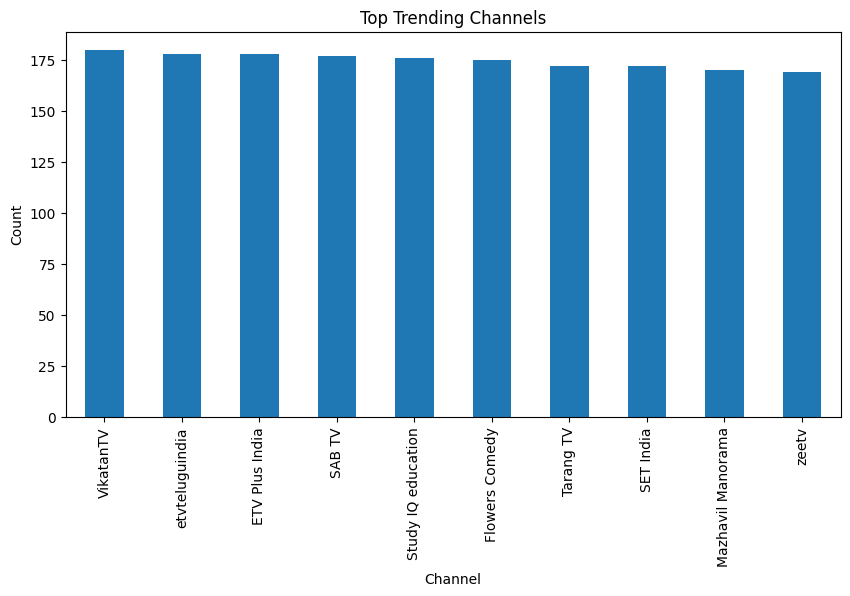

In [16]:
top_channels.plot(kind='bar', figsize=(10,5))

plt.title("Top Trending Channels")
plt.xlabel("Channel")
plt.ylabel("Count")
plt.show()

# Step-8:Views vs Likes Analysis

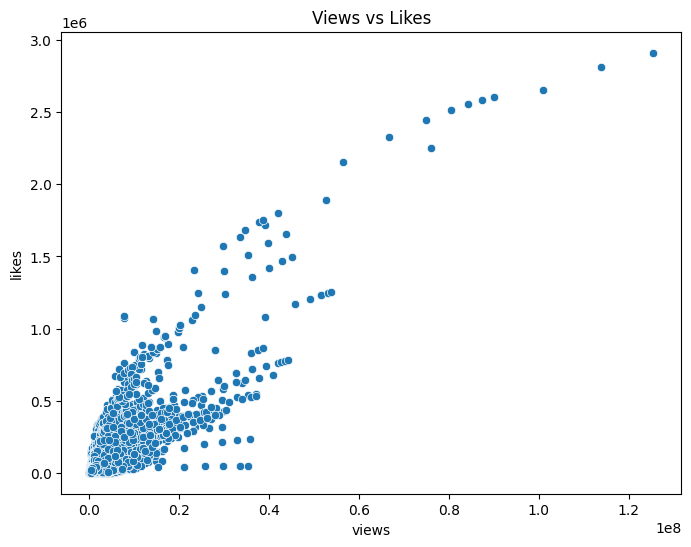

In [17]:
plt.figure(figsize=(8,6))

sns.scatterplot(x='views', y='likes', data=df)

plt.title("Views vs Likes")
plt.show()

# Step-9:Correlation Analysis

In [18]:
correlation = df[['views', 'likes', 'comment_count']].corr()

print(correlation)
df

                  views     likes  comment_count
views          1.000000  0.856493       0.742586
likes          0.856493  1.000000       0.824960
comment_count  0.742586  0.824960       1.000000


,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,kzwfHumJyYc,NaT,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False
1,zUZ1z7FwLc8,NaT,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False
2,10L1hZ9qa58,NaT,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False
3,N1vE8iiEg64,NaT,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False
4,kJzGH0PVQHQ,NaT,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32455,qjKxo910e94,NaT,10 AWESOME LIFE HACKS!,Power Vision,24,2018-05-16T12:15:00.000Z,"Life hacks|""Coca-Cola Life hacks""|""Useful Life...",381550,1258,342,92,False,False,False
32456,MYnO9Gfh5ks,NaT,20 WEIRD BEAUTY HACKS TESTED,5-Minute Crafts,26,2018-05-17T18:30:00.000Z,"5-Minute Crafts|""DIY""|""Do it yourself""|""crafts...",855750,11570,1057,817,False,False,False
32458,y-PQiShdTKA,NaT,Tochan (Full Video) | SIDHU MOOSEWALA | BYG BY...,Humble Music,10,2018-05-17T07:35:47.000Z,"sidhu moosewala|""sidhu moose wala""|""sidhu moos...",5659320,112533,3180,10480,False,False,False
32459,XiHiW4N7-bo,NaT,Mission: Impossible - Fallout (2018) - Officia...,Paramount Pictures,1,2018-05-16T06:59:59.000Z,"Official Trailer|""Movie""|""New Movie""|""Film""|""O...",9978294,129866,3645,9539,False,False,False


**Heatmap:**

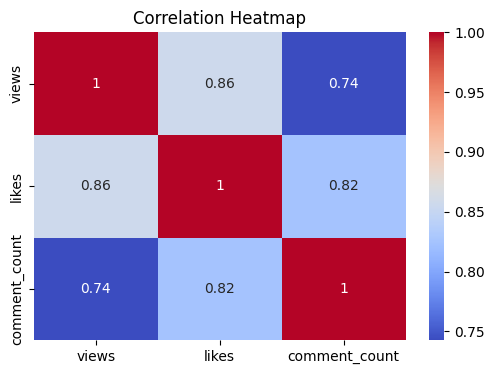

In [19]:
plt.figure(figsize=(6,4))

sns.heatmap(correlation, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

# Step-10:Most Commented Videos

In [20]:
top_comments = df.sort_values(by='comment_count', ascending=False)

top_comments[['title', 'comment_count']].head(10)
df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed
0,kzwfHumJyYc,NaT,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False
1,zUZ1z7FwLc8,NaT,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False
2,10L1hZ9qa58,NaT,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False
3,N1vE8iiEg64,NaT,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False
4,kJzGH0PVQHQ,NaT,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32455,qjKxo910e94,NaT,10 AWESOME LIFE HACKS!,Power Vision,24,2018-05-16T12:15:00.000Z,"Life hacks|""Coca-Cola Life hacks""|""Useful Life...",381550,1258,342,92,False,False,False
32456,MYnO9Gfh5ks,NaT,20 WEIRD BEAUTY HACKS TESTED,5-Minute Crafts,26,2018-05-17T18:30:00.000Z,"5-Minute Crafts|""DIY""|""Do it yourself""|""crafts...",855750,11570,1057,817,False,False,False
32458,y-PQiShdTKA,NaT,Tochan (Full Video) | SIDHU MOOSEWALA | BYG BY...,Humble Music,10,2018-05-17T07:35:47.000Z,"sidhu moosewala|""sidhu moose wala""|""sidhu moos...",5659320,112533,3180,10480,False,False,False
32459,XiHiW4N7-bo,NaT,Mission: Impossible - Fallout (2018) - Officia...,Paramount Pictures,1,2018-05-16T06:59:59.000Z,"Official Trailer|""Movie""|""New Movie""|""Film""|""O...",9978294,129866,3645,9539,False,False,False


# Step-11:Publishing Time Analysis

**Extract publish hour:**

In [21]:
df['publish_time'] = pd.to_datetime(df['publish_time'])

df['publish_hour'] = df['publish_time'].dt.hour
df

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,publish_hour
0,kzwfHumJyYc,NaT,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12 12:20:39+00:00,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False,12
1,zUZ1z7FwLc8,NaT,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13 05:43:56+00:00,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False,5
2,10L1hZ9qa58,NaT,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12 15:48:08+00:00,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False,15
3,N1vE8iiEg64,NaT,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12 07:08:48+00:00,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False,7
4,kJzGH0PVQHQ,NaT,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13 01:14:16+00:00,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32455,qjKxo910e94,NaT,10 AWESOME LIFE HACKS!,Power Vision,24,2018-05-16 12:15:00+00:00,"Life hacks|""Coca-Cola Life hacks""|""Useful Life...",381550,1258,342,92,False,False,False,12
32456,MYnO9Gfh5ks,NaT,20 WEIRD BEAUTY HACKS TESTED,5-Minute Crafts,26,2018-05-17 18:30:00+00:00,"5-Minute Crafts|""DIY""|""Do it yourself""|""crafts...",855750,11570,1057,817,False,False,False,18
32458,y-PQiShdTKA,NaT,Tochan (Full Video) | SIDHU MOOSEWALA | BYG BY...,Humble Music,10,2018-05-17 07:35:47+00:00,"sidhu moosewala|""sidhu moose wala""|""sidhu moos...",5659320,112533,3180,10480,False,False,False,7
32459,XiHiW4N7-bo,NaT,Mission: Impossible - Fallout (2018) - Officia...,Paramount Pictures,1,2018-05-16 06:59:59+00:00,"Official Trailer|""Movie""|""New Movie""|""Film""|""O...",9978294,129866,3645,9539,False,False,False,6


**Visualization:**

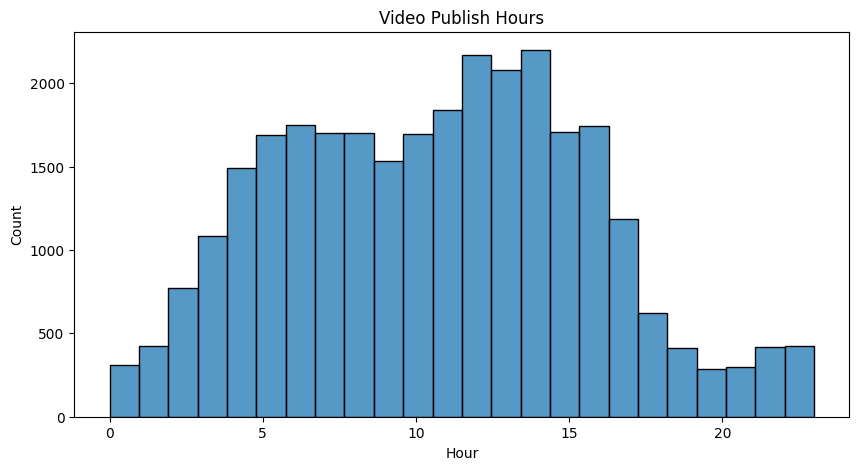

In [22]:
plt.figure(figsize=(10,5))

sns.histplot(df['publish_hour'], bins=24)

plt.title("Video Publish Hours")
plt.xlabel("Hour")
plt.show()

# Step-12:Business Insights

**Example Insights**

1.Music category trends most frequently.

2.Videos uploaded during evening get higher engagement.

3.High views strongly correlate with likes.

4.Some smaller channels achieve high engagement rates.

# Step-13:Final Dashboard Visualization

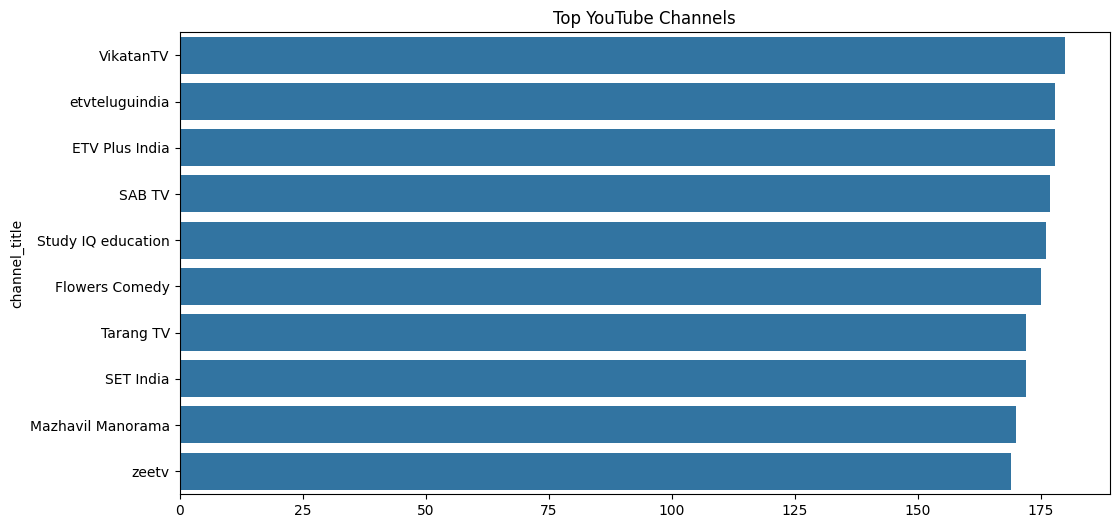

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_channels.values,
    y=top_channels.index
)

plt.title("Top YouTube Channels")
plt.show()